# **Análisis Exploratorio Inicial**

En este notebook se analiza el dataset de ingreso de viajeros internacionales a Guatemala con el fin de comprender algunos de los comportamientos reflejados en los datos. Asimismo, se busca identificar potenciales errores como valores faltantes, duplicados y valores atípicos.

## **Carga del dataset**

In [1]:
import pandas as pd

ruta_dataset = "../datos/raw/Base_Migracion_2009-2026jun.xlsx"
viajeros_internacionales = pd.read_excel(ruta_dataset, sheet_name="Datos")

## **Configuración para visualización**

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def formatear_miles(ax, eje='y'):
    formatter = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')
    if eje == 'y':
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


## **Preparación de la variable de fecha**

Se crea una columna `Fecha` para poder ordenar y agrupar los datos mes a mes.

In [3]:
viajeros_internacionales['Fecha'] = pd.to_datetime(
    viajeros_internacionales['Año'].astype(str) + '-' +
    viajeros_internacionales['Mes cod'].astype(str) + '-01'
)
viajeros_internacionales = viajeros_internacionales.sort_values('Fecha').reset_index(drop=True)

print('Fecha mínima:', viajeros_internacionales['Fecha'].min().strftime('%Y-%m'))
print('Fecha máxima:', viajeros_internacionales['Fecha'].max().strftime('%Y-%m'))
print('Frecuencia: mensual')
print('Número de registros:', len(viajeros_internacionales))


Fecha mínima: 2009-01
Fecha máxima: 2026-06
Frecuencia: mensual
Número de registros: 161036


## **a. Comportamiento temporal del número de viajeros**

Se grafica el número de viajeros por mes y por año. Se comparan dos series: el total de todos los tipos de viajero, y solo Turista + Excursionista, que es más comparable en todo el período (el enunciado explica que la categoría "Viajero" cambió de definición en 2023).

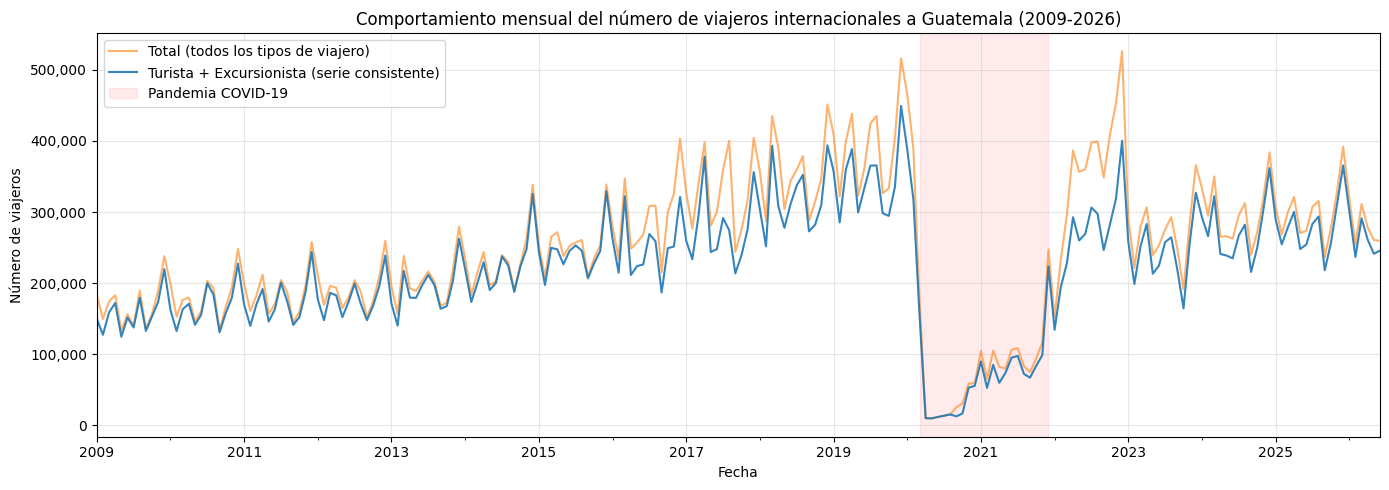

In [4]:
serie_mensual_total = viajeros_internacionales.groupby('Fecha')['Viajero'].sum()

serie_mensual_consistente = (
    viajeros_internacionales[viajeros_internacionales['Tipo de Viajero'].isin(['Turista', 'Excursionista'])]
    .groupby('Fecha')['Viajero'].sum()
)

fig, ax = plt.subplots(figsize=(14, 5))
serie_mensual_total.plot(ax=ax, label='Total (todos los tipos de viajero)', alpha=0.6, color='tab:orange')
serie_mensual_consistente.plot(ax=ax, label='Turista + Excursionista (serie consistente)', alpha=0.9, color='tab:blue')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-31'), color='red', alpha=0.08, label='Pandemia COVID-19')
ax.set_title('Comportamiento mensual del número de viajeros internacionales a Guatemala (2009-2026)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de viajeros')
formatear_miles(ax)
ax.legend()
plt.tight_layout()
plt.show()


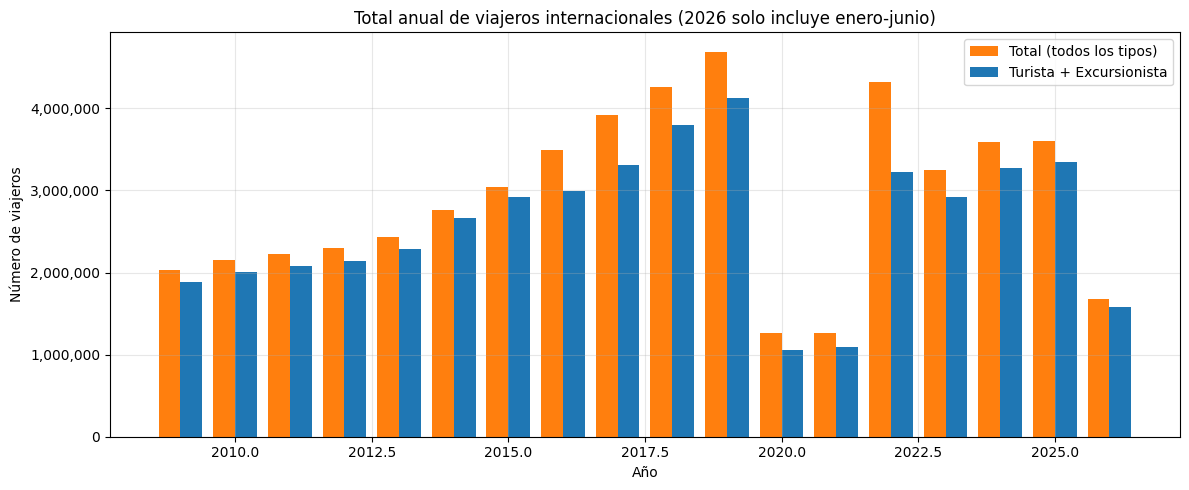

Variación porcentual anual (total, todos los tipos):
Año
2009      NaN
2010      6.1
2011      3.6
2012      3.1
2013      5.8
2014     13.6
2015     10.1
2016     14.9
2017     12.2
2018      8.5
2019     10.2
2020    -73.0
2021      0.1
2022    240.5
2023    -24.7
2024     10.6
2025      0.1
2026    -53.2
Name: Viajero, dtype: float64


In [5]:
serie_anual_total = viajeros_internacionales.groupby('Año')['Viajero'].sum()
serie_anual_consistente = (
    viajeros_internacionales[viajeros_internacionales['Tipo de Viajero'].isin(['Turista', 'Excursionista'])]
    .groupby('Año')['Viajero'].sum()
)

fig, ax = plt.subplots(figsize=(12, 5))
x = serie_anual_total.index
width = 0.4
ax.bar(x - width/2, serie_anual_total.values, width=width, label='Total (todos los tipos)', color='tab:orange')
ax.bar(x + width/2, serie_anual_consistente.values, width=width, label='Turista + Excursionista', color='tab:blue')
ax.set_title('Total anual de viajeros internacionales (2026 solo incluye enero-junio)')
ax.set_xlabel('Año')
ax.set_ylabel('Número de viajeros')
formatear_miles(ax)
ax.legend()
plt.tight_layout()
plt.show()

variacion = serie_anual_total.pct_change() * 100
print('Variación porcentual anual (total, todos los tipos):')
print(variacion.round(1))


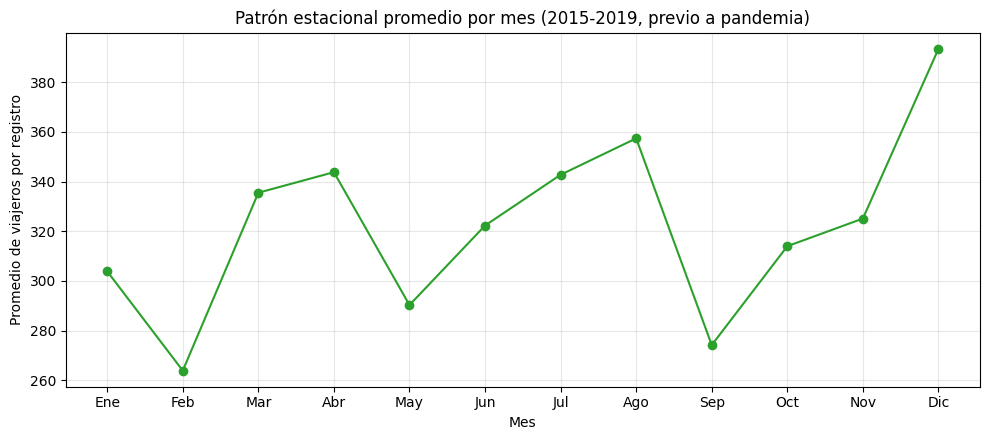

In [6]:
# Estacionalidad: promedio mensual (mes del año) usando años pre-pandemia sin distorsión metodológica (2015-2019)
estacionalidad = (
    viajeros_internacionales[(viajeros_internacionales['Año'] >= 2015) & (viajeros_internacionales['Año'] <= 2019)]
    .groupby('Mes cod')['Viajero'].mean()
)
meses_nombre = viajeros_internacionales[['Mes cod', 'Mes']].drop_duplicates().sort_values('Mes cod')['Mes']

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(meses_nombre.values, estacionalidad.values, marker='o', color='tab:green')
ax.set_title('Patrón estacional promedio por mes (2015-2019, previo a pandemia)')
ax.set_xlabel('Mes')
ax.set_ylabel('Promedio de viajeros por registro')
plt.tight_layout()
plt.show()


**Interpretación (a):**

- El número de viajeros creció de forma constante entre 2009 y 2019.
- En 2020 y 2021 hubo una caída muy fuerte por la pandemia.
- En 2023 el total baja, pero es principalmente por el cambio de definición de "Viajero", no porque haya menos turismo real; por eso se usa Turista + Excursionista para comparar.
- 2026 solo tiene datos hasta junio, por eso su total anual es más bajo.
- Se ve un patrón que se repite cada año (estacionalidad), con más viajeros en diciembre.

## **b. Países con mayor cantidad de viajeros**

Se suma el número de viajeros por país durante todo el período para ver cuáles son los que más aportan.

,Total de viajeros (2009-2026)
País,
El Salvador,1.621398e+07
Guatemala,1.479233e+07
Estados Unidos de América,7.047843e+06
Honduras,2.788233e+06
México,1.808946e+06
Belice,1.328256e+06
Nicaragua,1.164343e+06
Cruceristas,1.078372e+06
Costa Rica,8.821797e+05


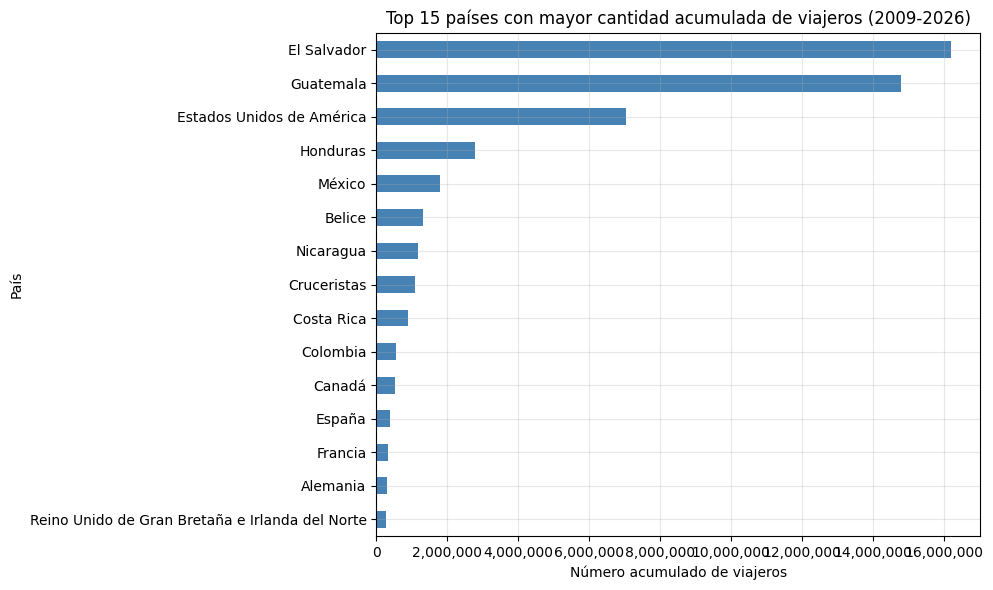

In [7]:
total_por_pais = (
    viajeros_internacionales.groupby('País')['Viajero'].sum()
    .sort_values(ascending=False)
)

top15_paises = total_por_pais.head(15)
display(top15_paises.to_frame('Total de viajeros (2009-2026)'))

fig, ax = plt.subplots(figsize=(10, 6))
top15_paises.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 países con mayor cantidad acumulada de viajeros (2009-2026)')
ax.set_xlabel('Número acumulado de viajeros')
formatear_miles(ax, eje='x')
plt.tight_layout()
plt.show()


In [8]:
top3_paises = total_por_pais.head(3)
total_general = total_por_pais.sum()

print('Top 3 países (criterio de acumulado total, usado como base para las series obligatorias por país):')
print(top3_paises)
print()
print(f'Participación del Top 3 sobre el total acumulado: {top3_paises.sum() / total_general * 100:.1f}%')
print(f'Participación del Top 5 sobre el total acumulado: {total_por_pais.head(5).sum() / total_general * 100:.1f}%')
print(f'Número de países/orígenes distintos registrados: {total_por_pais.shape[0]}')


Top 3 países (criterio de acumulado total, usado como base para las series obligatorias por país):
País
El Salvador                  1.621398e+07
Guatemala                    1.479233e+07
Estados Unidos de América    7.047843e+06
Name: Viajero, dtype: float64

Participación del Top 3 sobre el total acumulado: 72.8%
Participación del Top 5 sobre el total acumulado: 81.6%
Número de países/orígenes distintos registrados: 235


**Interpretación (b):**

- Los países con más viajeros son El Salvador, Guatemala y Estados Unidos.
- Son en su mayoría países vecinos, lo que tiene sentido por el ingreso terrestre.
- Pocos países concentran la mayoría de los viajeros; el resto aporta muy poco.
- Existe una categoría "Cruceristas" dentro de País que no es un país real, se revisará más adelante.

## **c. Regiones con mayor cantidad de viajeros**

Se usa la variable `Región dos` para agrupar por región geográfica y ver cuáles aportan más viajeros.

,Total de viajeros (2009-2026)
Región dos,
América Del Centro,3.740653e+07
América Del Norte,9.383035e+06
Europa,2.222621e+06
América Del Sur y el Caribe,1.447950e+06
Cruceristas,1.078372e+06
Asia,4.217025e+05
Oceanía,1.400472e+05
Oriente Medio,1.357125e+05
Cruceros,2.603000e+04


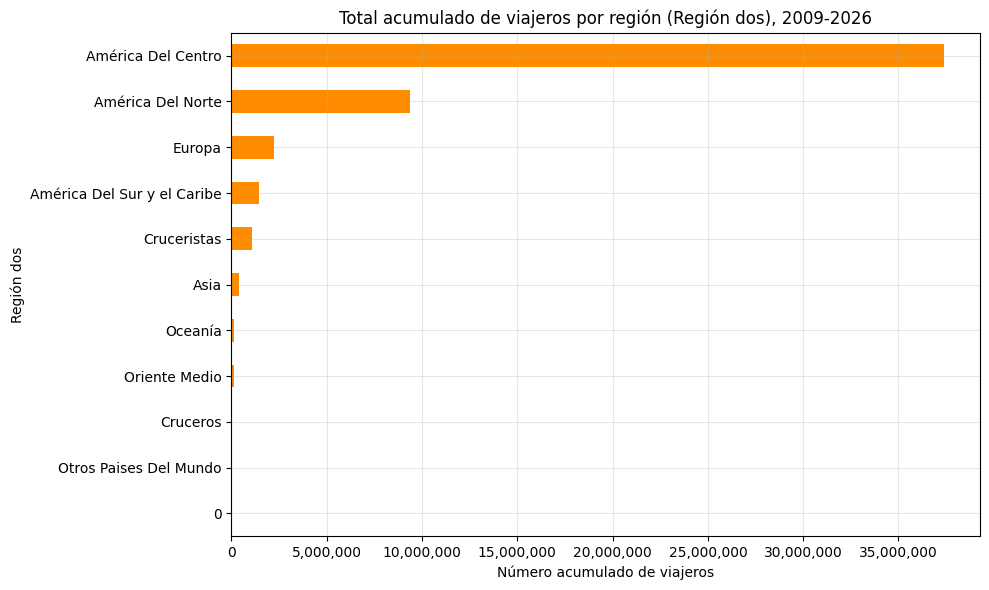

In [9]:
total_por_region = (
    viajeros_internacionales.groupby('Región dos')['Viajero'].sum()
    .sort_values(ascending=False)
)

display(total_por_region.to_frame('Total de viajeros (2009-2026)'))

fig, ax = plt.subplots(figsize=(10, 6))
total_por_region.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Total acumulado de viajeros por región (Región dos), 2009-2026')
ax.set_xlabel('Número acumulado de viajeros')
formatear_miles(ax, eje='x')
plt.tight_layout()
plt.show()


Top 3 regiones (criterio de acumulado total, usado como base para las series obligatorias por región):
Región dos
América Del Centro    3.740653e+07
América Del Norte     9.383035e+06
Europa                2.222621e+06
Name: Viajero, dtype: float64

Participación del Top 3 sobre el total acumulado: 93.7%


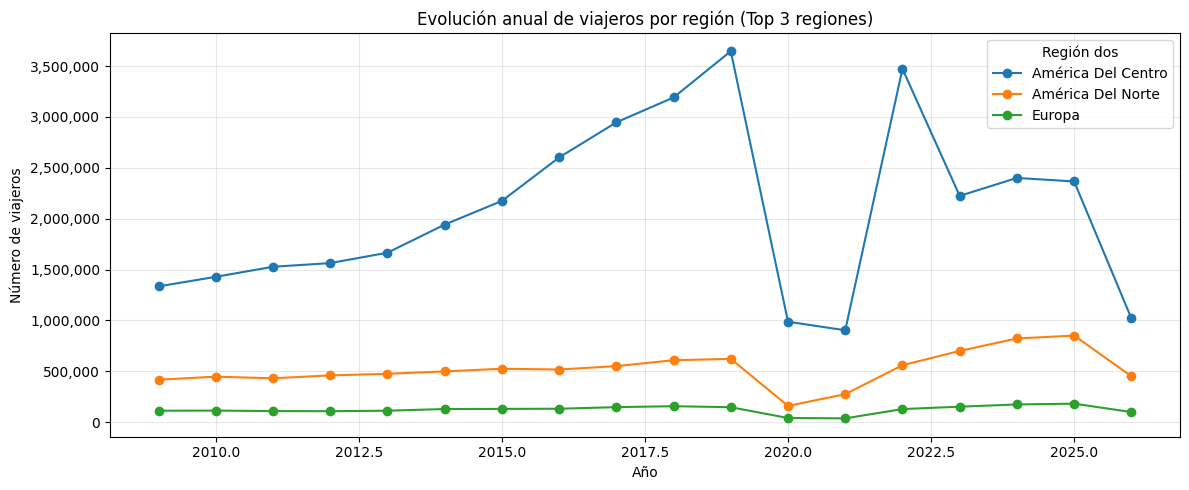

In [10]:
top3_regiones = total_por_region.head(3)
total_general_region = total_por_region.sum()

print('Top 3 regiones (criterio de acumulado total, usado como base para las series obligatorias por región):')
print(top3_regiones)
print()
print(f'Participación del Top 3 sobre el total acumulado: {top3_regiones.sum() / total_general_region * 100:.1f}%')

# Evolución anual de las 3 regiones principales
top3_anual = (
    viajeros_internacionales[viajeros_internacionales['Región dos'].isin(top3_regiones.index)]
    .groupby(['Año', 'Región dos'])['Viajero'].sum()
    .unstack()
)

fig, ax = plt.subplots(figsize=(12, 5))
top3_anual.plot(ax=ax, marker='o')
ax.set_title('Evolución anual de viajeros por región (Top 3 regiones)')
ax.set_xlabel('Año')
ax.set_ylabel('Número de viajeros')
formatear_miles(ax)
plt.tight_layout()
plt.show()


**Interpretación (c):**

- La región con más viajeros es América Del Centro, seguida de América Del Norte y Europa.
- Esto coincide con lo visto en países: los vecinos cercanos aportan más viajeros.
- Todas las regiones bajaron durante la pandemia, y América Del Centro es la que más bajó y subió en números absolutos.
- Hay categorías como "Cruceristas", "Cruceros" y "0" que no son regiones reales; se revisarán más adelante.